# Ch01

## bandit

In [22]:
import numpy as np

class Bandit:

    def __init__(self, arms=10):
        self.rates = np.random.rand(arms)

    def play(self, arm):
        if np.random.rand() > self.rates[arm]:
            return 0
        return 1

bandit = Bandit()
bandit.play(0)

1

### Agent

In [185]:
class Agent:

    def __init__(self, epsilon, action_size=10):
        self.epsilon = epsilon
        self.Qs = [0] * action_size
        self.Ns = [0] * action_size

        # 记录探索次数
        self.counter = 0
        
    def update(self, action, reward):
        self.Ns[action] += 1
        self.Qs[action] += (reward - self.Qs[action]) / self.Ns[action]
        
    def get_action(self):
        if np.random.rand() < self.epsilon:
            self.counter += 1
            return np.random.randint(0, len(self.Qs))
        return np.argmax(self.Qs)

### Run

7946 2927


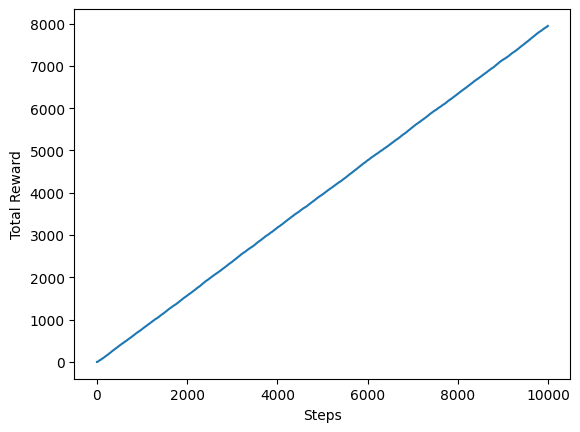

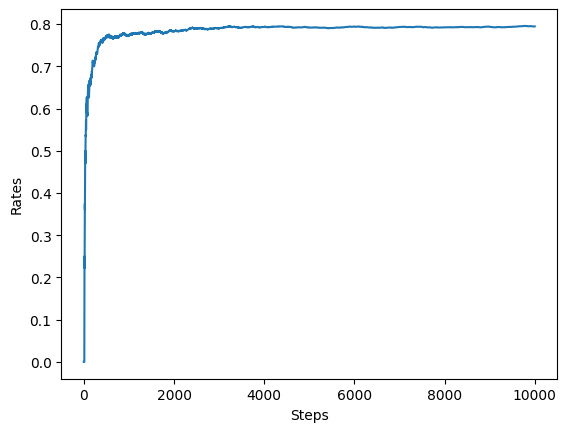

In [196]:
import matplotlib.pyplot as plt

steps = 10000
epsilon = 0.3

bandit = Bandit()
agent = Agent(epsilon)
total_reward = 0
total_rewards = []
rates = []

for step in range(steps):
    action = agent.get_action()
    reward = bandit.play(action)
    agent.update(action, reward)

    total_reward += reward
    total_rewards.append(total_reward)
    rates.append(total_reward / (step + 1))

print(total_reward, agent.counter)

plt.ylabel('Total Reward')
plt.xlabel('Steps')
plt.plot(total_rewards)
plt.show()

plt.ylabel('Rates')
plt.xlabel('Steps')
plt.plot(rates)
plt.show()

### Agent Avg

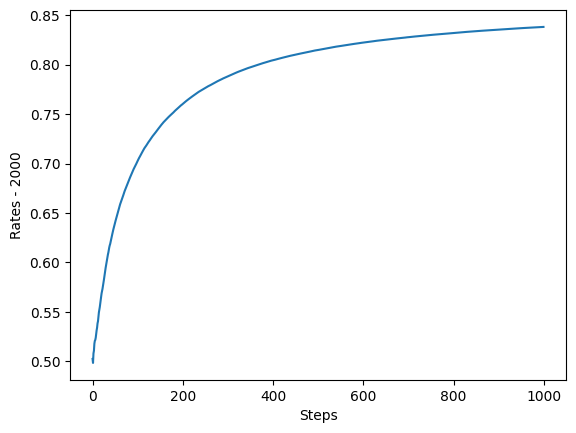

In [193]:
import matplotlib.pyplot as plt

runs = 2000
steps = 1000
epsilon = 0.1
all_rates = np.zeros((runs, steps))

for run in range(runs):
    bandit = Bandit()
    agent = Agent(epsilon)
    
    total_reward = 0
    rates = []
    
    for step in range(steps):
        action = agent.get_action()
        reward = bandit.play(action)
        agent.update(action, reward)
    
        total_reward += reward
        total_rewards.append(total_reward)
        rates.append(total_reward / (step + 1))

    # numpy 是复制, 列表就是改引用
    all_rates[run] = rates

plt.ylabel(f'Rates - {runs}')
plt.xlabel('Steps')
plt.plot(np.average(all_rates, axis=0))
plt.show()

## Non-Stationary Bandit

In [211]:
class NonStatBandit:

    def __init__(self, arms=10):
        self.rates = np.random.rand(arms)

    def play(self, arm):
        self.rates[arm] += 0.1 * np.random.randn()
        if np.random.rand() < self.rates[arm]:
            return 1
        return 0

### AlphaAgent

In [214]:
class AlphaAgent:

    def __init__(self, epsilon, alpha, action_size=10):
        self.epsilon = epsilon
        self.alpha = alpha
        self.Qs = [0] * action_size
        self.Ns = [0] * action_size

        # 记录探索次数
        self.counter = 0
        
    def update(self, action, reward):
        self.Ns[action] += 1
        self.Qs[action] += (reward - self.Qs[action]) * self.alpha
        
    def get_action(self):
        if np.random.rand() < self.epsilon:
            self.counter += 1
            return np.random.randint(0, len(self.Qs))
        return np.argmax(self.Qs)

### 当作稳态问题处理

7050 3085


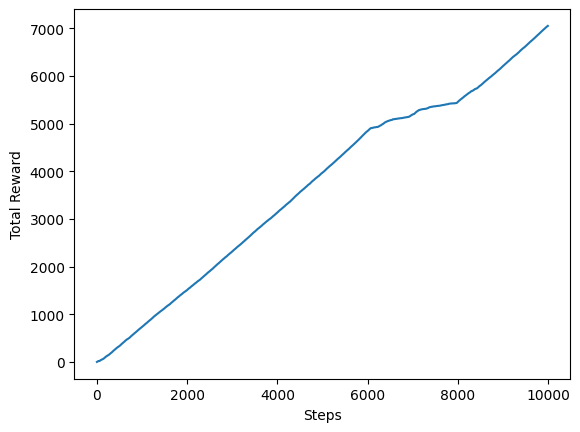

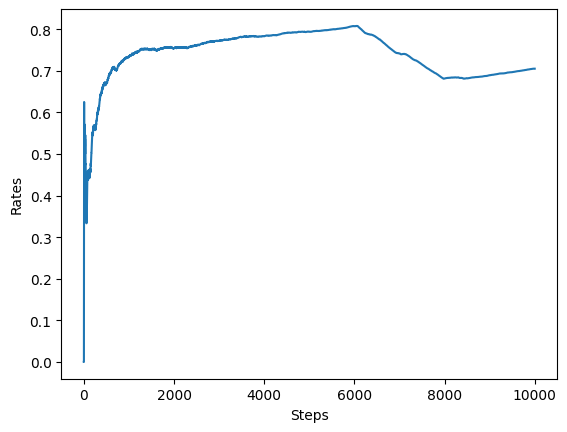

In [209]:
import matplotlib.pyplot as plt

steps = 10000
epsilon = 0.3

bandit = NonStatBandit()
agent = Agent(epsilon)
total_reward = 0
total_rewards = []
rates = []

for step in range(steps):
    action = agent.get_action()
    reward = bandit.play(action)
    agent.update(action, reward)

    total_reward += reward
    total_rewards.append(total_reward)
    rates.append(total_reward / (step + 1))

print(total_reward, agent.counter)

plt.ylabel('Total Reward')
plt.xlabel('Steps')
plt.plot(total_rewards)
plt.show()

plt.ylabel('Rates')
plt.xlabel('Steps')
plt.plot(rates)
plt.show()

### 当作非稳态问题处理

7984 2994


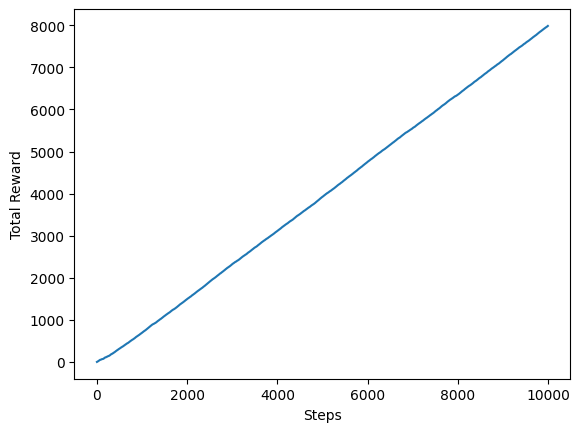

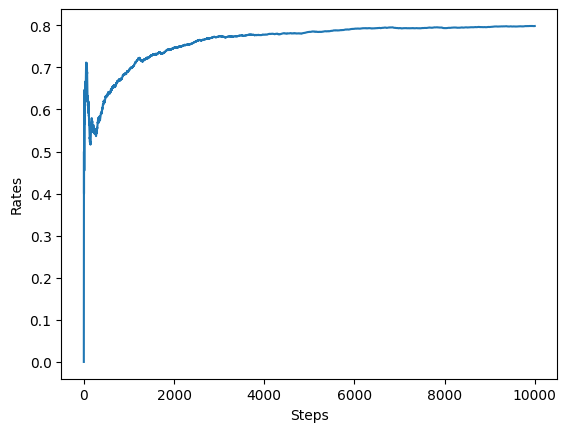

In [218]:
import matplotlib.pyplot as plt

steps = 10000
epsilon = 0.3
alpha = 0.8

bandit = NonStatBandit()
agent = AlphaAgent(epsilon, alpha)
total_reward = 0
total_rewards = []
rates = []

for step in range(steps):
    action = agent.get_action()
    reward = bandit.play(action)
    agent.update(action, reward)

    total_reward += reward
    total_rewards.append(total_reward)
    rates.append(total_reward / (step + 1))

print(total_reward, agent.counter)

plt.ylabel('Total Reward')
plt.xlabel('Steps')
plt.plot(total_rewards)
plt.show()

plt.ylabel('Rates')
plt.xlabel('Steps')
plt.plot(rates)
plt.show()

# Ch02